# **DL Lab 8: 18th September, 2025**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**

In [11]:
import numpy as np
import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Resizing, Dropout, GlobalAveragePooling2D
from keras.applications import VGG16
from keras.optimizers import SGD, Adam, RMSprop
from keras.utils import to_categorical
import keras_tuner as kt
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import tensorflow as tf

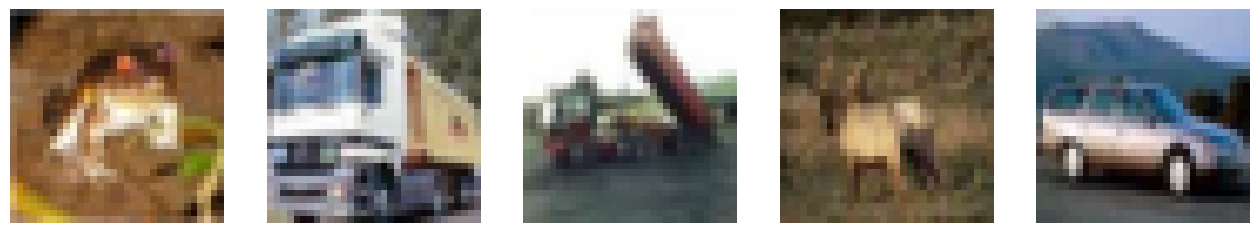

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
fig, axs = plt.subplots(1, 5, figsize=(16, 4))
for i in range(5):
    axs[i].imshow(X_train[i])
    axs[i].axis('off')    
plt.show()


In [4]:
print(f"Shape of X_train: {X_train.shape} and X_test: {X_test.shape}")

Shape of X_train: (50000, 32, 32, 3) and X_test: (10000, 32, 32, 3)


In [3]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train/255
X_test = X_test/255

In [5]:
model1 = Sequential()
model1.add(Conv2D(30, 5, strides=[1,1], activation='relu', padding='valid', input_shape=(32,32, 3)))
model1.add(MaxPool2D(pool_size=(2,2), strides=(2,2), padding='valid'))
model1.add(Conv2D(20, 5, strides=(1, 1), activation="relu", padding='valid'))
model1.add(MaxPool2D(pool_size=(2,2), strides=(1,1), padding="valid"))
model1.add(Conv2D(10, 3, strides=(1, 1), activation="relu", padding='valid'))
model1.add(MaxPool2D(pool_size=(2,2), strides=(1,1), padding="valid"))
model1.add(Flatten())
model1.add(Dense(100, activation='relu'))
model1.add(Dense(100, activation='softmax'))
model1.summary()


e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 30)     │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 20)     │        15,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 10)       │         1,810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        36,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,310 (255.12 KB)

 Trainable params: 65,310 (255.12 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
estop = EarlyStopping(monitor = 'val_loss', min_delta = 1e-4, mode= 'min', patience=4, verbose = 1, restore_best_weights=True)

In [7]:
model1.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
hist1 = model1.fit(X_train, y_train, batch_size=56, epochs=20, verbose=1, validation_data=(X_test, y_test), callbacks=[estop])

Epoch 1/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2228 - loss: 2.1977 - val_accuracy: 0.4064 - val_loss: 1.5836
Epoch 2/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4416 - loss: 1.5217 - val_accuracy: 0.4630 - val_loss: 1.4696
Epoch 3/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4835 - loss: 1.4206 - val_accuracy: 0.5112 - val_loss: 1.3580
Epoch 4/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5140 - loss: 1.3291 - val_accuracy: 0.5279 - val_loss: 1.2977
Epoch 5/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5375 - loss: 1.2856 - val_accuracy: 0.5215 - val_loss: 1.3091
Epoch 6/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5515 - loss: 1.2394 - val_accuracy: 0.5621 - val_loss: 1.2257
Epoch 7/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5643 - loss: 1.2060 - val_accuracy: 0.5693 - val_loss: 1.2014
Epoch 8/20
893/893 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5794 - loss: 1.1679 - val_accuracy: 0.

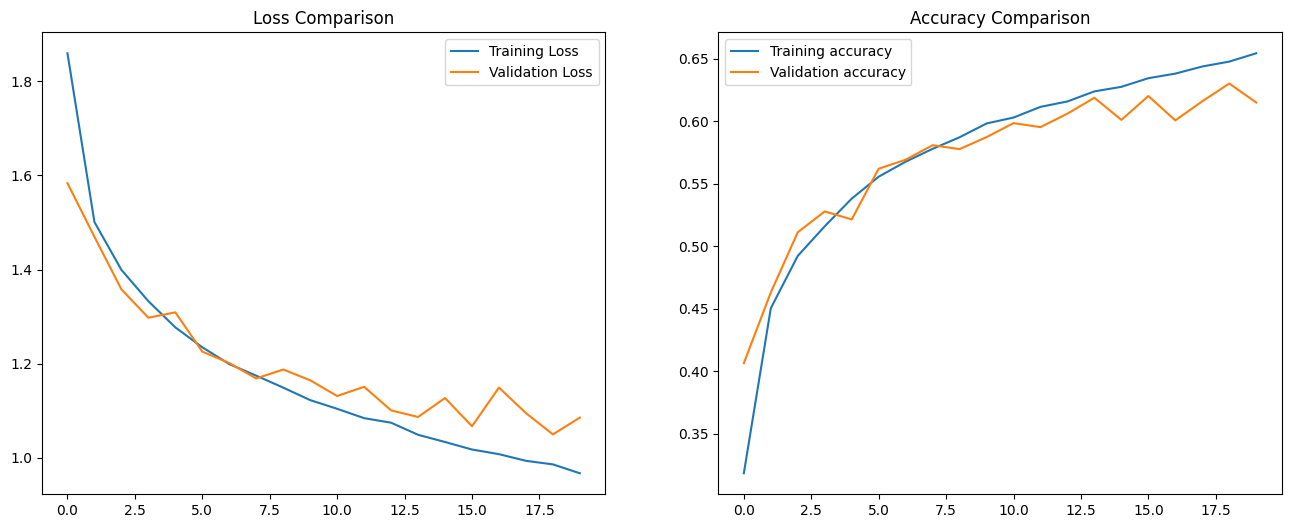

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].plot(hist1.history['loss'], label='Training Loss')
axs[0].plot(hist1.history['val_loss'], label='Validation Loss')
axs[0].set_title('Loss Comparison')
axs[1].plot(hist1.history['accuracy'], label='Training accuracy')
axs[1].plot(hist1.history['val_accuracy'], label='Validation accuracy')
axs[1].set_title('Accuracy Comparison')
axs[0].legend()
axs[1].legend()
plt.show()

# **Question 2**

In [10]:
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 141s 2us/step


In [17]:
model2 = Sequential()
model2.add(Resizing(224, 224, input_shape=(32,32,3)))
model2.add(base_model)
model2.add(GlobalAveragePooling2D())
model2.add(Flatten())
model2.add(Dense(100, activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(50, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(10, activation='softmax'))

model2.summary()
model2.compile(loss="sparse_categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

e:\VIT Study Materials\SEM 3\Deep Learning\LAB\.venv\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_4 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,771,548 (56.35 MB)

 Trainable params: 56,860 (222.11 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
hist2 = model2.fit(X_train, y_train, batch_size=56, epochs=20, verbose=1, validation_data=(X_test, y_test), callbacks=[estop])